# Velocity of a Toy Car Measured with Ultrasonic Motion Detector
##### By Reid Mumford and Liza Sazonova  (Original data collected: 9/13/2018)
---

## Introduction



The goal is to measure the position as a function of time for a toy truck.  The position will be measured with a *Vernier* Ultrasonic Motion Detector. 

We know that (in the absence of acceleration),

$$ x(t) = v t + x_o$$

Assuming the truck doesn't accelerate, we can find its velocity by looking at the position of the truck at different times, and calculating the slope of the graph with position on the y-axis and time on the x-axis. To do this, we set up the experiment using a toy truck, a tape measure and Vernier motion detector.

## Setup 

 * Place the motion detector about 10 cm from the tape measure
 * Place the car with the tape between the wheels, to reduce the chance of the car going off-track. 
 * Connect the motion detector to the LabPro device


<img src = "images/DSC_0702.jpg" width=400 style="float:left; margin-right: 20px; transform: rotate(-90deg)">



## First Try

### Charging the Car
It is observed that the speed of the car depends on how far the car is initially pulled back. 

## Charging Protocol:
**We decide to pull the car backwards 40 cm to wind up the motor.** 

### Data Collection
Then we start the motion detector and release the car. After the car has reached the other wall, we stop the LoggerPro measurement. Figure below shows the data that was collected in the LoggerPro software window:

<img src="images/screenshot1.png" width=800>

It looks like LoggerPro did not record the motion of the car; instead it recorded a constant position at 2.23 m. We guess that the detector misses the car since it is too much to the side, and measures the next closest object: the wall. We check this guess.

#### Measured distances
 * distance from the edge of table to the wall $ = 244.0 \pm 0.5 cm$ 
 * distance from the edge of table to front of motion detector $ = 17.0 \pm 0.5 cm$
 * calculated distance from detector to wall:

## Moving Position of the Motion Detector

We moved the motion detector to rest on the tape measure for better alignment. 

We measured the length of the detector from the table edge again to obtain a more accurate estimate of the detector length, and we got

#### Measured Distances
distance from the edge of table to front of motion detector $= 16.7 \pm 0.1 cm$


<img src="images/DSC_0703.jpg" width=400 style="float: left; margin-right:20px; transform: rotate(90deg)"> 

## Test Data: 
We pull the car back to the motion detector and start a new measurement. The position data on the LoggerPro preview looks clean. 
The car starts accelerating around 1s after LoggerPro is started, and moved with roughly constant velocity for about 2 seconds. It then stops as it hits the wall. 

### Observations: 
 * There is a small bump at $t\approx 1.6$ s, and we are not sure what caused it. 
 * There is also a strange spike in the velocity plot, shown below.

<img src="images/screenshot2.png" width=800>

### Spike Issue
The spike was caused when the motion detector misses the car for one data point.   We switched the detector to a lower sensitivity setting to try for cleaner data. 

### Range of the Motion Detector
We noticed that the initial position on the position graph reads $17$ cm, even though the car started directly in front of the detector. 

The range of the motion detector is listed in the user manual: https://www.vernier.com/files/manuals/md-btd/md-btd.pdf
The range is: 
$$ 0.17 m < r < 6.0 m$$

### Charging the Car -- Improved Procedure
Based on the limitation of the motion detector, we change our procedure slightly:
 * Start the car at the $80$ cm mark (measured from the back bumper)
 * Pull back to $40$ cm mark (still $40$ cm pull-back)
 * Release

The first two trials, the car went off track, so we decided to discard these. The next trial was successful and we obtained good quality data, shown below.

<img src="images/screenshot5.png" width=800>

# Data Collection

Using our updated protocol we collect data for several trips of the car down the track.  One data set is shown below. 

In [1]:
import pandas as pd 
data1 = pd.read_csv("data/data4.csv")

Look at one of the data files to make sure it was read in correctly:

In [2]:
data1.head()  # Looks at only the top 5 rows

,Time (s),Position (m),Velocity (m/s),Acceleration (m/s²)
0,0.05,0.228301,0.003964,-0.031725
1,0.10,0.228575,0.002210,-0.025441
2,0.15,0.228575,0.000823,-0.015524
3,0.20,0.228575,0.000610,-0.006276
4,0.25,0.228575,0.001220,-0.013271


It looks good! Now, we want to calculate the velocity from the part of the run where the car was actually moving with a constant speed and not accelerating. Looking at the plot above, it looks like the car was moving roughly constantly past $0.5$ cm, and until about $2$ m. We choose this region in all data files:

In [3]:
vel_data1 = data1[(data1["Position (m)"] > 0.5) & (data1["Position (m)"] < 2)]

# Quick Visualization of Data

To quickly make sure our selection makes sense, we plot the three runs and make sure the data is roughly linear. LoggerPro's uncertainties in time are negligible.  The uncertainty in position is determined by the resolution of the motion detector ($\pm 1mm$) it is safe to ignore the uncertainty in position. We use the `errorbar` plot with 0 uncertainties.

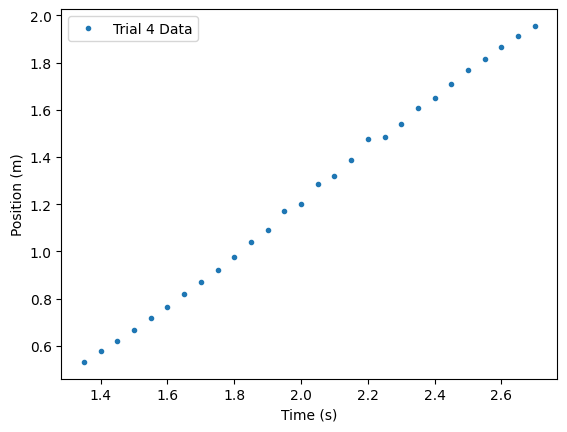

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.errorbar(vel_data1["Time (s)"], vel_data1["Position (m)"], fmt=".", label="Trial 4 Data")

plt.xlabel("Time (s)"); plt.ylabel("Position (m)"); plt.legend()

# Modeling the Data

It looks like the selection is correct. Interestingly, we can immediately see that the slopes are slightly different between Runs 1 and 2, indicating a slightly different velocity, although this might not be a significant effect.

To get a numerical value for velocity, we fit a straight line to each of the data sets. We use a linear model:
$$y = A + Bx$$

In [6]:
def linear_model(x, A, B):
    y = A + B*x
    return y

We use SciPy's `curve_fit` function from the `optimize` toolbox to fit for parameters A and B and their associated uncertainties. Since LoggerPro's uncertainties are negligible, we do not specify the `sigma` and `absolute_sigma` parameters.

In [10]:
from scipy.optimize import curve_fit
import numpy as np

fit_values1, fit_cov1 = curve_fit(linear_model, # linear model
                                  vel_data1["Time (s)"], # x-data
                                  vel_data1["Position (m)"]) # y-data
                                  
                        

A1 = fit_values1[0];  dA1 = np.sqrt(fit_cov1[0][0])
B1 = fit_values1[1];  dB1 = np.sqrt(fit_cov1[1][1])
print("Curve Fit Results")
print(" Intercept: %f +/- %f" % (A1,dA1))
print(" Slope: %f +/- %f" % (B1,dB1)) 

Curve Fit Results
 Intercept: -0.964084 +/- 0.015180
 Slope: 1.088893 +/- 0.007351


# Visualize Data and Model

Text(0.5, 1.0, 'Toy Truck Trip Measured with\n Ultrasonic Motion Detector')

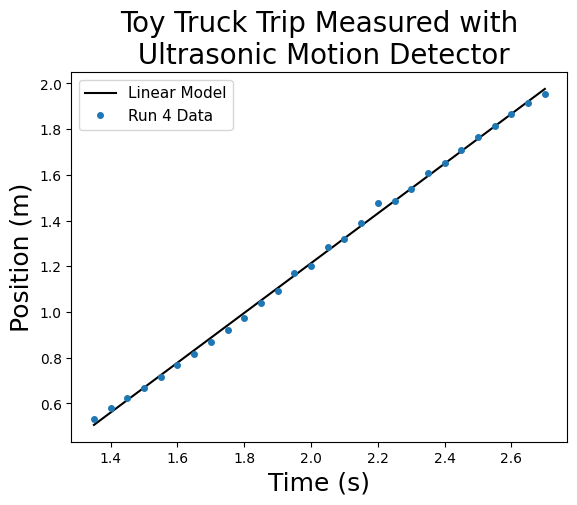

In [26]:
# Plot the data
plt.errorbar(vel_data1["Time (s)"], # x-data
             vel_data1["Position (m)"], # y-data
             fmt="o", markersize=4, # formatting
             label="Run 4 Data") # label

# Plot the line fit
plt.plot(vel_data1["Time (s)"], # x-data
         linear_model(vel_data1["Time (s)"], A1, B1), # y-data
         color="black", # formatting
         label="Linear Model") # label

# Beautify the Plot
plt.xlabel("Time (s)", fontsize=18)
plt.ylabel("Position (m)", fontsize=18)
plt.legend(fontsize=11)
plt.title("Toy Truck Trip Measured with\n Ultrasonic Motion Detector",fontsize=20)

# Result -- Velocity of the Toy Car

The speed of the toy car is measured with the ultrasonic motion detector to be: 
$$\boxed{v_{\text{motion detector}} = 1.089 \pm 0.007 \text{(m/s)}}$$

The intercept is not consistent with 0, but it is to be expected, since the intercept corresponds to the position when t=0, but for all of the trials the car didn't start moving at t=0. Therefore, a negative intercept is to be expected.

## Results and Discussion

We have investigated the velocity of a toy truck using LoggerPro motion detector. 
 * We assumed that the car is moving with a constant speed, and its position is given as a function of time: $x(t) = vt + x_o$. 
 * We fit a linear model to the data we collected, $x = A + Bx$, and found the speed of the car from the slope of the linear fit for each trial. 
 * The linear model appears to describe the data well.  It seems that the constant velocity assumption is reasonable. 
 